In [14]:
!hostname

hgn39.wexac.weizmann.ac.il


In [15]:
import os
import sys
import numpy as np
import pandas as pd
import logging
from NOVA.manuscript.manuscript_figures_data_config_RANBP17_exp import (
    RANBP17_exp_MARKERS,
    RANBP17_exp_MARKERS_TO_EXCLUDE,
    RANBP17_exp_BATCHES,
    RANBP17_exp_CELL_LINES,
    RANBP17_exp_ALL_CONDITIONS,
    RANBP17_exp_ALL_KD_CONDITIONS,
    RANBP17_exp_ALL_CONTROL_CONDITIONS,
)

MODEL_PATH = "/home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen"
# ---WORKING ENV SETUP---
NOVA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA'
NOVA_DATA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA'
NOVA_LOCAL = "/home/projects/hornsteinlab/Collaboration/Guy_Lior"
OUTPUT_DIR = os.path.join(NOVA_LOCAL, "RANBP17_exp", "Outliers")
CONFIG_PATHS = [
    "./NOVA/manuscript/manuscript_figures_data_config_RANBP17_exp/RANBP17_exp_BaseFigureConfig",
]

MARKERS = RANBP17_exp_MARKERS
# RANBP17_exp_MARKERS_TO_EXCLUDE is None in the data config; the helpers below call
# list(...) on this, so normalize to an empty list here.
MARKERS_TO_EXCLUDE = list(RANBP17_exp_MARKERS_TO_EXCLUDE) if RANBP17_exp_MARKERS_TO_EXCLUDE else []
KD_LIST = RANBP17_exp_ALL_KD_CONDITIONS
CONTROL_LIST = RANBP17_exp_ALL_CONTROL_CONDITIONS
CONDITIONS_LIST = RANBP17_exp_ALL_CONDITIONS

BATCHES = list(RANBP17_exp_BATCHES)
CELL_LINES = list(RANBP17_exp_CELL_LINES)

D = 1.5
os.environ['NOVA_HOME'] = NOVA_HOME
os.environ['NOVA_LOCAL'] = NOVA_LOCAL
sys.path.insert(1, os.getenv("NOVA_HOME"))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")
print(f"NOVA_LOCAL: {os.getenv('NOVA_LOCAL')}")
print(f"Conditions:   {CONDITIONS_LIST}")
print(f"KDs:          {KD_LIST}")
print(f"Controls:     {CONTROL_LIST}")
print(f"Markers:      {MARKERS}")

from src.analysis.analyzer_umap import AnalyzerUMAP
from src.common.utils import load_config_file, get_class
from src.embeddings.embeddings_utils import load_embeddings


%load_ext autoreload
%autoreload 2

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
NOVA_LOCAL: /home/projects/hornsteinlab/Collaboration/Guy_Lior
Conditions:   ['tardp-kd', 'ranbp17-kd', 'control-179', 'control-180', 'both-kd', 'untreated']
KDs:          ['tardp-kd', 'ranbp17-kd', 'both-kd']
Controls:     ['control-179', 'control-180', 'untreated']
Markers:      ['DAPI', 'TDP-43', 'RANBP17']
NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA


In [16]:
# --- imports for spec-driven UMAP ---
from src.datasets.label_utils import (
    MapLabelsFunction,
    get_reps_from_labels, get_batches_from_labels,
    get_cell_lines_from_labels, get_conditions_from_labels,
    get_cell_lines_conditions_from_labels, get_markers_from_labels,
)
from NOVA.manuscript.manuscript_plot_config_RANBP17_exp import RANBP17_exp_BasePlotConfig

In [17]:
def load_data_config(config_path: str, markers: list, markers_to_exclude: list, batches: list = None, conditions: list = None):

    run_config = load_config_file(config_path, 'data', savefolder=NOVA_LOCAL)
    run_config.OUTPUTS_FOLDER = MODEL_PATH
    run_config.MARKERS = markers
    run_config.MARKERS_TO_EXCLUDE = markers_to_exclude
    run_config.BATCHES = batches
    run_config.INPUT_FOLDERS = [os.path.join(run_config.PROCESSED_FOLDER_ROOT, f) for f in batches]
    run_config.CONDITIONS = conditions

    embeddings, labels, paths = load_embeddings(MODEL_PATH, run_config)
    return run_config, embeddings, labels, paths

In [18]:
def compute_umap(config_path, embeddings: np.ndarray,
                 n_components: int = 2, **umap_kwargs) -> np.ndarray:
    """Run UMAP on embeddings. Pass n_components=3 for a 3D embedding.
    Extra kwargs (n_neighbors, min_dist, metric, ...) are forwarded to umap.UMAP."""
    anz = AnalyzerUMAP(config_path, MODEL_PATH)
    return anz._compute_umap_embeddings(embeddings, n_components=n_components, **umap_kwargs)

In [19]:
def compute_distances(embedding: np.ndarray):
    # embedding shape: (n_samples, n_dimensions)
    centroid = np.median(embedding, axis=0, keepdims=True)
    # Distances to centroid
    dists = np.linalg.norm(embedding - centroid, axis=1)
    return dists

In [20]:
def find_outliers(distances: np.ndarray, d=1.5):
    q1 = np.percentile(distances, 25)
    q3 = np.percentile(distances, 75)
    iqr = q3 - q1
    upper_bound = q3 + d * iqr
    outliers_mask = (distances > upper_bound)
    return outliers_mask, upper_bound

In [21]:
def plot_distribution(data: np.ndarray, title: str, xlabel: str, mark=None, output_path=None):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=50, alpha=0.7)
    if mark is not None:
        plt.axvline(x=mark, color='r', linestyle='--', label='Outlier Threshold')
        plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(True)
    if output_path is not None:
        plt.savefig(os.path.join(output_path))
    plt.show()
    plt.close()

In [22]:
def plot_umap(umap_embeddings: np.ndarray, labels: pd.DataFrame, title: str, output_path: str = None, outliers: dict = None):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=umap_embeddings[:, 0], y=umap_embeddings[:, 1], color='grey', s=5)
    if outliers is not None:
        colors = sns.color_palette('tab10', n_colors=len(outliers))
        for i, key in enumerate(outliers):
            mask = outliers[key]["indices"]
            print(f"Plotting {len(umap_embeddings[mask])} outliers for {key}")
            plt.scatter(umap_embeddings[mask, 0], umap_embeddings[mask, 1], color=colors[i], s=20, label=f'{key}')
    plt.title(title)
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    plt.show()
    plt.close()

In [23]:
def filter_data(keys_list, value_list, data_list, total_len):
    combined_mask = np.ones((total_len,), dtype=bool)
    for keys, value in zip(keys_list, value_list):
        assert len(keys) == total_len, "Data length must match keys length"
        current_condition_mask = (keys == value)
        combined_mask = combined_mask & current_condition_mask
    final_indices = np.where(combined_mask)[0]
    filtered_data = [data[combined_mask] for data in data_list]
    return final_indices, filtered_data

In [24]:
def save_summary_json(outliers_dict: dict, d: float, output_path: str):
    import json
    summary = {}
    total_samples = 0
    total_outliers = 0
    for key, data in outliers_dict.items():
        samples = data["num_samples"]
        outliers = len(data["paths"])
        total_samples += samples
        total_outliers += outliers
        summary[key] = {
            "num_samples": int(samples),
            "num_outliers": int(outliers),
            "upper_bound": float(data["upper_bound"]),
            "paths": data["paths"].tolist()
        }
    summary["total"] = {
        "num_samples": int(total_samples),
        "num_outliers": int(total_outliers),
        "outliers_d_threshold": d,
    }

    summary = dict(sorted(summary.items(), key=lambda item: item[0] != "total"))

    with open(output_path, 'w') as f:
        json.dump(summary, f, indent=4)

In [25]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def load_tile(path, tile):
    """
    args:
        path: path of the original img (shape: num_tiles, H, W, num_ch)
    returns:
        marker, nucleus, overlay (Green for marker, Blue for nucleus)
    """
    image = np.load(path)
    site_image = image[tile]
    marker = site_image[:, :, 0]
    nucleus = site_image[:, :, 1]

    marker = (marker - marker.min()) / (marker.max() - marker.min())
    nucleus = (nucleus - nucleus.min()) / (nucleus.max() - nucleus.min())

    overlay = np.zeros((*marker.shape, 3))
    overlay[..., 2] = nucleus
    overlay[..., 1] = marker
    return marker, nucleus, overlay


def example_outliers_images(outliers_dict: dict, output_dir: str, num_samples: int = 5):
    os.makedirs(output_dir, exist_ok=True)

    for group, data in outliers_dict.items():
        paths = data["paths"]
        n = min(len(paths), num_samples)
        if n == 0:
            print(f"No outliers found for group {group}. Skipping...")
            continue

        sample_paths = random.sample(list(paths), n)
        m = (n // 5) + int(n % 5 != 0)
        fig, axes = plt.subplots(m, 5, figsize=(5 * 3, m * 3))
        flat_axes = axes.flatten()

        for i, img_path in enumerate(sample_paths):
            ax = flat_axes[i]
            npy_path = img_path.split('.npy/')[0] + '.npy'
            tile = img_path.split('.npy/')[1]
            try:
                marker, nucleus, overlay = load_tile(npy_path, int(tile))
                ax.imshow(overlay)
                ax.set_title(f"{os.path.basename(npy_path)}, tile {tile}", fontsize=8)
            except Exception as e:
                ax.text(0.5, 0.5, f"Error loading\n{os.path.basename(img_path)}",
                        ha='center', va='center')
            ax.axis('off')

        plt.suptitle(f"Group: {group} - Random Outlier Examples")
        save_path = os.path.join(output_dir, f"{group}_outliers.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()

In [26]:
from src.datasets.label_utils import get_batches_from_labels, get_cell_lines_from_labels
def parse_group(batch, cell_line,
                run_config, embeddings, labels, paths,
                d):
    group = f"{batch}_{cell_line}"

    batches = get_batches_from_labels(labels, run_config)
    cell_lines = get_cell_lines_from_labels(labels, run_config)
    filtered_idx, [filtered_emb, filtered_paths] = filter_data(
        [batches, cell_lines], [batch, cell_line], [embeddings, paths], len(labels))

    filtered_distances = compute_distances(filtered_emb)
    filtered_outliers_mask, upper_bound = find_outliers(filtered_distances, d=d)

    return len(filtered_emb), group, upper_bound, filtered_idx[filtered_outliers_mask], filtered_paths[filtered_outliers_mask], filtered_distances

In [27]:
# --- pipeline ----

def pipeline(marker_name, output_dir=None, d=2.0, num_imgs: int = 5):
    run_config, embeddings, labels, paths = load_data_config(
        config_path=CONFIG_PATHS[0],
        markers=[marker_name],
        markers_to_exclude=MARKERS_TO_EXCLUDE,
        batches=BATCHES,
        conditions=CONDITIONS_LIST,
    )
    umap_embeddings = compute_umap(run_config, embeddings)
    outliers_dict = {}
    for batch in BATCHES:
        for cell_line in CELL_LINES:
            num_samples, group, upper_bound, outliers_indices, outliers_paths, group_distances = parse_group(
                batch, cell_line, run_config, embeddings, labels, paths, d)
            outliers_dict[group] = {
                "num_samples": num_samples,
                "group": group,
                "upper_bound": upper_bound,
                "indices": outliers_indices,
                "paths": outliers_paths,
            }
            plot_distribution(
                data=group_distances,
                title=f"{marker_name} {group}: Distribution of Distances to Centroid",
                xlabel="Distance", mark=upper_bound,
                output_path=os.path.join(output_dir, f"{marker_name}_{group}_distance_distribution.png"),
            )
    save_summary_json(outliers_dict, d, output_path=os.path.join(output_dir, f"{marker_name}_outliers_summary.json"))
    plot_umap(umap_embeddings, labels, f"{marker_name}:UMAP with Outliers",
              outliers=outliers_dict,
              output_path=os.path.join(output_dir, f"{marker_name}_umap_with_outliers.png"))
    example_outliers_images(outliers_dict,
                            output_dir=os.path.join(output_dir, "outliers_images"),
                            num_samples=num_imgs)

In [28]:
for marker in MARKERS:
    output_dir = os.path.join(OUTPUT_DIR, f"d_{D}", marker)
    os.makedirs(output_dir, exist_ok=True)
    print("*" * 50)
    print(f"Processing marker: {marker}")
    # pipeline(marker, output_dir=output_dir, d=D, num_imgs=30)

**************************************************
Processing marker: DAPI
**************************************************
Processing marker: TDP-43
**************************************************
Processing marker: RANBP17


# Spec-driven UMAP — single configurable run

Mirrors the spec format from `ranbp17_exp_umap_runs.ipynb`, but computes the UMAP **locally in this notebook** and plots it inline. Useful for quick exploration without submitting bsub jobs.

A run is a dict:

```python
spec = {
    "data": {
        "name": "AllCond_TDP43",
        "batches": ["batch1"],
        "cell_lines": ["iW11"],
        "conditions": [...],
        "markers": ["TDP-43"],
        "markers_to_exclude": [],
    },
    "plot": {
        "color_by": "condition",   # rep / batch / condition / cell_line / cell_line_condition / marker
        "size": 8,
        "color_overrides": {"ranbp17-kd": "#E41A1C"},  # optional
    },
}
```

Then call `run_umap_spec(spec, find_outliers_per_group=True)` to compute the UMAP, optionally detect outliers per `(batch, cell_line)` group on the full embedding, and overlay them inline as black-edged circles.

**Spec keys (subset):**

| `data` key | `plot` key |
|---|---|
| `name` | `color_by` (required) |
| `batches`, `cell_lines`, `conditions` | `size`, `alpha`, `figsize` |
| `markers`, `markers_to_exclude` | `color_overrides` ({group: '#hex'}) |
| `input_folders` | `n_components`, `control_conditions`, `alpha_z_gradient`, `alpha_range` |

In [29]:
# color_by -> (default UMAP type, MapLabelsFunction member, color attr on RANBP17_exp_BasePlotConfig)
COLOR_BY_MAP = {
    "rep":                 (0, "REPS",                  "COLOR_MAPPINGS_RANBP17_EXP_REPS"),
    "batch":               (0, "BATCHES",               "COLOR_MAPPINGS_RANBP17_EXP_BATCHES"),
    "condition":           (0, "CONDITIONS",            "COLOR_MAPPINGS_RANBP17_EXP_CONDITIONS"),
    "cell_line":           (0, "CELL_LINES",            "COLOR_MAPPINGS_RANBP17_EXP_CELL_LINES"),
    "cell_line_condition": (0, "CELL_LINES_CONDITIONS", "COLOR_MAPPINGS_RANBP17_EXP_CELL_LINE_CONDITIONS"),
    "marker":              (1, "MARKERS",               "COLOR_MAPPINGS_RANBP17_EXP_MARKERS"),
}

# spec data-key -> attribute set on the run_config (DatasetConfig)
SPEC_DATA_KEY_TO_ATTR = {
    "input_folders":      "INPUT_FOLDERS",
    "cell_lines":         "CELL_LINES",
    "conditions":         "CONDITIONS",
    "markers":            "MARKERS",
    "markers_to_exclude": "MARKERS_TO_EXCLUDE",
    "batches":            "BATCHES",
    "add_rep_to_label":   "ADD_REP_TO_LABEL",
    "add_batch_to_label": "ADD_BATCH_TO_LABEL",
}


def load_run_config_from_spec(spec_data: dict, config_path: str = None):
    """Build a run_config from a spec's `data` dict, then load embeddings.

    If the spec doesn't list `batches` / `markers_to_exclude`, the global BATCHES /
    MARKERS_TO_EXCLUDE defaults are applied. INPUT_FOLDERS is always re-derived
    from BATCHES.
    """
    config_path = config_path or CONFIG_PATHS[0]
    run_config = load_config_file(config_path, 'data', savefolder=NOVA_LOCAL)
    run_config.OUTPUTS_FOLDER = MODEL_PATH

    if "batches" not in spec_data:
        run_config.BATCHES = list(BATCHES)
    if "markers_to_exclude" not in spec_data:
        run_config.MARKERS_TO_EXCLUDE = list(MARKERS_TO_EXCLUDE)

    for key, attr in SPEC_DATA_KEY_TO_ATTR.items():
        if key in spec_data:
            setattr(run_config, attr, spec_data[key])

    if getattr(run_config, "BATCHES", None):
        run_config.INPUT_FOLDERS = [
            os.path.join(run_config.PROCESSED_FOLDER_ROOT, b)
            for b in run_config.BATCHES
        ]

    embeddings, labels, paths = load_embeddings(MODEL_PATH, run_config)
    return run_config, embeddings, labels, paths


def get_group_labels(labels: np.ndarray, run_config, color_by: str) -> np.ndarray:
    """Map per-sample labels to the group string used for coloring."""
    if color_by not in COLOR_BY_MAP:
        raise ValueError(f"Unknown color_by={color_by!r}. Valid: {sorted(COLOR_BY_MAP)}")
    map_func_name = COLOR_BY_MAP[color_by][1]
    fn = MapLabelsFunction[map_func_name].value[0]
    return fn(labels, run_config)


def _categorical_palette(items, cmap_name='hsv'):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    n = max(len(items), 2)
    cmap = plt.get_cmap(cmap_name, n)
    return {item: mcolors.to_hex(cmap(i)) for i, item in enumerate(items)}


def build_palette(group_labels: np.ndarray, color_by: str, color_overrides: dict = None) -> dict:
    """Return {group_name: '#hex'}.

    For 'condition' / 'cell_line_condition' a fresh categorical palette is built sized
    to the unique groups present (so few-condition UMAPs get distinct colors).
    For other modes we pull from RANBP17_exp_BasePlotConfig's static color mappings.
    """
    base = RANBP17_exp_BasePlotConfig()
    unique_groups = list(dict.fromkeys(np.asarray(group_labels).tolist()))

    if color_by == "condition":
        cmap_dict = base.make_condition_palette(unique_groups)
    elif color_by == "cell_line_condition":
        cmap_dict = {g: {base.MAPPINGS_ALIAS_KEY: g, base.MAPPINGS_COLOR_KEY: hex_color}
                     for g, hex_color in _categorical_palette(unique_groups).items()}
    else:
        color_attr = COLOR_BY_MAP[color_by][2]
        cmap_dict = dict(getattr(base, color_attr))

    palette = {}
    for g in unique_groups:
        entry = cmap_dict.get(g)
        if isinstance(entry, dict):
            palette[g] = entry[base.MAPPINGS_COLOR_KEY]
        elif isinstance(entry, str):
            palette[g] = entry
        else:
            palette[g] = '#888888'

    if color_overrides:
        for k, v in color_overrides.items():
            palette[k] = v if isinstance(v, str) else v.get(base.MAPPINGS_COLOR_KEY, '#888888')
    return palette


def compute_control_medoid(embeddings: np.ndarray,
                           labels: np.ndarray,
                           run_config,
                           control_conditions) -> int:
    """Index (into `embeddings`) of the control sample whose original embedding is
    closest to the centroid of all control embeddings. Returns -1 if no controls match."""
    sample_conds = np.asarray(get_conditions_from_labels(labels, run_config))
    ctrl_mask = np.isin(sample_conds, list(control_conditions))
    if not ctrl_mask.any():
        return -1
    ctrl_idx = np.where(ctrl_mask)[0]
    ctrl_emb = embeddings[ctrl_idx]
    centroid = np.mean(ctrl_emb, axis=0)
    dists = np.linalg.norm(ctrl_emb - centroid, axis=1)
    return int(ctrl_idx[int(np.argmin(dists))])


def plot_umap_colored(umap_embeddings: np.ndarray,
                      group_labels: np.ndarray,
                      palette: dict,
                      title: str,
                      outliers_dict: dict = None,
                      output_path: str = None,
                      size: float = 8,
                      alpha: float = 0.85,
                      figsize=None,
                      extra_markers: dict = None,
                      alpha_z_gradient: bool = None,
                      alpha_range=(0.2, 0.95)):
    """Plot UMAP colored by groups. Auto-detects 2D vs 3D from umap_embeddings.shape[1].

    extra_markers: {label: array-like (length 2 or 3)} drawn as black-edged red stars.
    alpha_z_gradient: per-point alpha varies linearly with the Z coord. None=auto.
    """
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    n_dim = umap_embeddings.shape[1]
    if n_dim not in (2, 3):
        raise ValueError(f"plot_umap_colored expects 2D or 3D UMAP, got {n_dim}D")

    if alpha_z_gradient is None:
        alpha_z_gradient = (n_dim == 3)
    use_z_alpha = bool(alpha_z_gradient) and n_dim == 3

    if figsize is None:
        figsize = (10, 8) if n_dim == 2 else (10, 9)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d') if n_dim == 3 else fig.add_subplot(111)
    extra_kw_3d = {"depthshade": False} if n_dim == 3 else {}

    per_point_alpha = None
    if use_z_alpha:
        z = umap_embeddings[:, 2]
        z_lo, z_hi = float(z.min()), float(z.max())
        z_span = max(z_hi - z_lo, 1e-9)
        a_lo, a_hi = float(alpha_range[0]), float(alpha_range[1])
        per_point_alpha = a_lo + (z - z_lo) / z_span * (a_hi - a_lo)

    group_arr = np.asarray(group_labels)
    unique_groups = list(dict.fromkeys(group_arr.tolist()))
    for g in unique_groups:
        mask = (group_arr == g)
        coords = [umap_embeddings[mask, i] for i in range(n_dim)]
        if use_z_alpha:
            rgb = mcolors.to_rgb(palette.get(g, '#888888'))
            rgba = np.zeros((int(mask.sum()), 4))
            rgba[:, :3] = rgb
            rgba[:, 3] = per_point_alpha[mask]
            ax.scatter(*coords, c=rgba, s=size, label=str(g),
                       edgecolors='none', **extra_kw_3d)
        else:
            ax.scatter(*coords, color=palette.get(g, '#888888'),
                       s=size, alpha=alpha, label=str(g),
                       edgecolors='none', **extra_kw_3d)

    if outliers_dict is not None:
        total_out = 0
        for key, data in outliers_dict.items():
            idx = data["indices"]
            if len(idx) == 0:
                continue
            total_out += len(idx)
            coords = [umap_embeddings[idx, i] for i in range(n_dim)]
            ax.scatter(*coords, facecolors='none', edgecolors='black',
                       s=size * 4.0, linewidth=0.7,
                       label=f'outliers:{key} (n={len(idx)})', **extra_kw_3d)
        if total_out:
            print(f"Marked {total_out} outliers across {len(outliers_dict)} group(s).")

    if extra_markers:
        for marker_label, coord in extra_markers.items():
            coord = np.asarray(coord).reshape(-1)
            if coord.size != n_dim:
                print(f"  skipping marker {marker_label!r}: expected {n_dim} coords, got {coord.size}")
                continue
            ax.scatter(*[coord[i] for i in range(n_dim)],
                       marker='*', s=max(size * 30, 350),
                       color='red', edgecolors='black', linewidths=1.0,
                       label=marker_label, zorder=10, **extra_kw_3d)

    ax.set_title(title)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    if n_dim == 3:
        ax.set_zlabel('UMAP 3')
    ncol = 2 if len(unique_groups) > 25 else 1
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=ncol)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()


def run_umap_spec(spec: dict,
                  output_dir: str = None,
                  d: float = 1.5,
                  find_outliers_per_group: bool = False,
                  config_path: str = None,
                  num_imgs: int = 0,
                  show_distance_distribution: bool = True):
    """Compute + plot a UMAP from a single spec dict (data + plot).

    spec['plot'] keys:
        color_by (required)
        n_components       — 2 or 3 (default 2)
        size, alpha, figsize, color_overrides
        control_conditions — list of condition names; the medoid (computed on the
                             original embeddings) is overlaid as a red star.
        alpha_z_gradient   — bool, default None=auto (on for 3D).
        alpha_range        — (low, high), default (0.2, 0.95)
    """
    spec_data = spec.get("data", {})
    spec_plot = spec.get("plot", {})
    name = spec_data.get("name", "unnamed")
    color_by = spec_plot.get("color_by", "condition")
    size = spec_plot.get("size", 8)
    alpha = spec_plot.get("alpha", 0.85)
    n_components = int(spec_plot.get("n_components", 2))
    figsize = spec_plot.get("figsize", None)
    control_conditions = spec_plot.get("control_conditions", None)
    alpha_z_gradient = spec_plot.get("alpha_z_gradient", None)
    alpha_range = spec_plot.get("alpha_range", (0.2, 0.95))

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)

    print(f"[{name}] loading embeddings...")
    run_config, embeddings, labels, paths = load_run_config_from_spec(spec_data, config_path)
    if len(embeddings) == 0:
        print(f"[{name}] no embeddings matched spec filters; aborting.")
        return None
    print(f"[{name}] loaded {len(embeddings)} embeddings; computing {n_components}D UMAP...")

    umap_embeddings = compute_umap(run_config, embeddings, n_components=n_components)

    group_labels = get_group_labels(labels, run_config, color_by)
    palette = build_palette(group_labels, color_by, spec_plot.get("color_overrides"))

    outliers_dict = None
    if find_outliers_per_group:
        outliers_dict = {}
        batches_arr = get_batches_from_labels(labels, run_config)
        cell_lines_arr = get_cell_lines_from_labels(labels, run_config)
        unique_pairs = sorted({(b, c) for b, c in zip(batches_arr, cell_lines_arr)})
        for batch, cell_line in unique_pairs:
            num_samples, group, upper_bound, outliers_indices, outliers_paths, group_distances = \
                parse_group(batch, cell_line, run_config, embeddings, labels, paths, d)
            outliers_dict[group] = {
                "num_samples": num_samples,
                "group": group,
                "upper_bound": upper_bound,
                "indices": outliers_indices,
                "paths": outliers_paths,
            }
            if show_distance_distribution:
                dist_out = (os.path.join(output_dir, f"{name}_{group}_distance_distribution.png")
                            if output_dir else None)
                plot_distribution(
                    data=group_distances,
                    title=f"{name} {group}: Distance distribution",
                    xlabel="Distance", mark=upper_bound, output_path=dist_out,
                )
        if output_dir is not None:
            save_summary_json(outliers_dict, d,
                              output_path=os.path.join(output_dir, f"{name}_outliers_summary.json"))
            if num_imgs > 0:
                example_outliers_images(outliers_dict,
                                        output_dir=os.path.join(output_dir, "outliers_images"),
                                        num_samples=num_imgs)

    extra_markers = None
    medoid_idx = -1
    if control_conditions:
        medoid_idx = compute_control_medoid(embeddings, labels, run_config, control_conditions)
        if medoid_idx >= 0:
            n_ctrl = int(np.isin(np.asarray(get_conditions_from_labels(labels, run_config)),
                                 list(control_conditions)).sum())
            print(f"[{name}] control medoid: global idx {medoid_idx} (of {n_ctrl} control samples)")
            extra_markers = {"control medoid": umap_embeddings[medoid_idx]}
        else:
            print(f"[{name}] WARNING: no samples matched control_conditions={control_conditions}; medoid skipped")

    suffix = "" if n_components == 2 else f"_{n_components}d"
    plot_path = os.path.join(output_dir, f"{name}_umap{suffix}.png") if output_dir else None
    plot_umap_colored(umap_embeddings, group_labels, palette,
                      title=f"{name}: {n_components}D UMAP colored by {color_by}",
                      outliers_dict=outliers_dict, output_path=plot_path,
                      size=size, alpha=alpha, figsize=figsize,
                      extra_markers=extra_markers,
                      alpha_z_gradient=alpha_z_gradient,
                      alpha_range=alpha_range)

    return {
        "name": name,
        "umap": umap_embeddings,
        "labels": labels,
        "paths": paths,
        "group_labels": group_labels,
        "palette": palette,
        "outliers": outliers_dict,
        "run_config": run_config,
        "n_components": n_components,
        "control_medoid_idx": medoid_idx if medoid_idx >= 0 else None,
    }

In [30]:
# --- Configure a single UMAP run ---
spec = {
    "data": {
        "name": "AllCond_TDP43",
        "batches": BATCHES,
        "cell_lines": CELL_LINES,
        "conditions": CONDITIONS_LIST,
        "markers": ["TDP-43"],
        "markers_to_exclude": MARKERS_TO_EXCLUDE,
    },
    "plot": {
        "color_by": "condition",   # rep / batch / condition / cell_line / cell_line_condition / marker
        "size": 8,
        # "color_overrides": {"ranbp17-kd": "#E41A1C"},  # optional per-group color
    },
}

# result = run_umap_spec(
#     spec,
#     output_dir=None,
#     d=D,
#     find_outliers_per_group=True,
#     num_imgs=0,
# )

# --- Example: binary control vs KD coloring ---
CTRL_COLOR = "#1F77B4"
KD_COLOR   = "#D62728"
controls = set(CONTROL_LIST)
conds    = KD_LIST + CONTROL_LIST
overrides = {c: (CTRL_COLOR if c in controls else KD_COLOR) for c in conds}
spec_binary = {
    "data": {"name": "BinaryCtrlKD_TDP43", "batches": BATCHES,
             "cell_lines": CELL_LINES, "conditions": conds,
             "markers": ["TDP-43"], "markers_to_exclude": MARKERS_TO_EXCLUDE},
    "plot": {"color_by": "condition", "size": 12, "color_overrides": overrides},
}
# result_bin = run_umap_spec(spec_binary, find_outliers_per_group=True)

2026-05-20 11:08:04 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:04 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:04 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:04 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:04 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:04 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:04 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:04 INFO: [embeddings_utils._filter] conditions = ['control-179', 'tardp-kd']
2026-05-20 11:08:04 INFO: [load_embeddings] embeddings shape: (2044, 192)
2026-05

[control-179_vs_tardp-kd_RANBP17] loading embeddings...
[control-179_vs_tardp-kd_RANBP17] loaded 2044 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


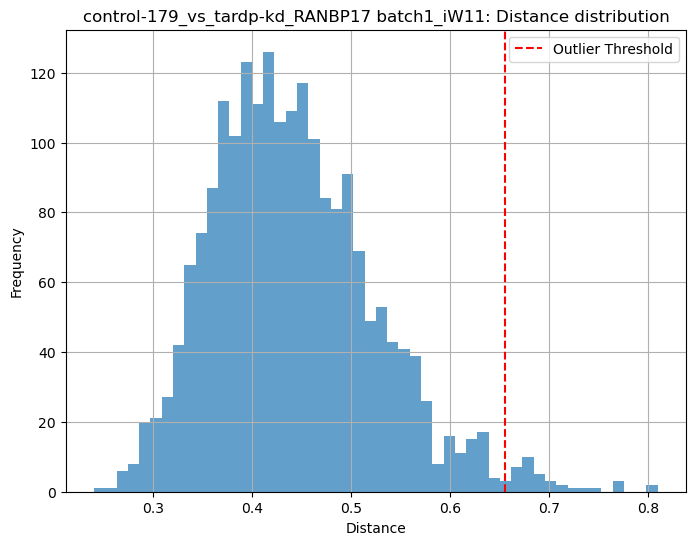

[control-179_vs_tardp-kd_RANBP17] control medoid: global idx 361 (of 976 control samples)
Marked 38 outliers across 1 group(s).


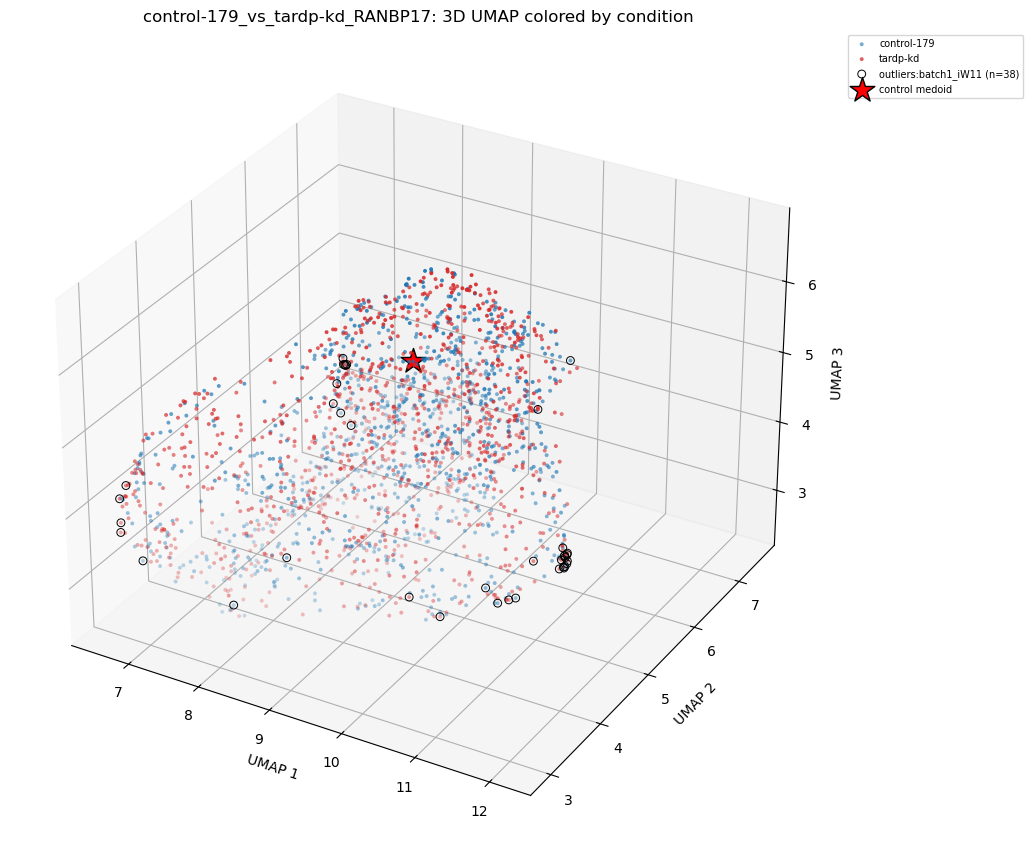

2026-05-20 11:08:09 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:09 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:09 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:09 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:09 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:09 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:09 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:09 INFO: [embeddings_utils._filter] conditions = ['control-179', 'ranbp17-kd']
2026-05-20 11:08:09 INFO: [load_embeddings] embeddings shape: (1970, 192)
2026-

[control-179_vs_ranbp17-kd_RANBP17] loading embeddings...
[control-179_vs_ranbp17-kd_RANBP17] loaded 1970 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


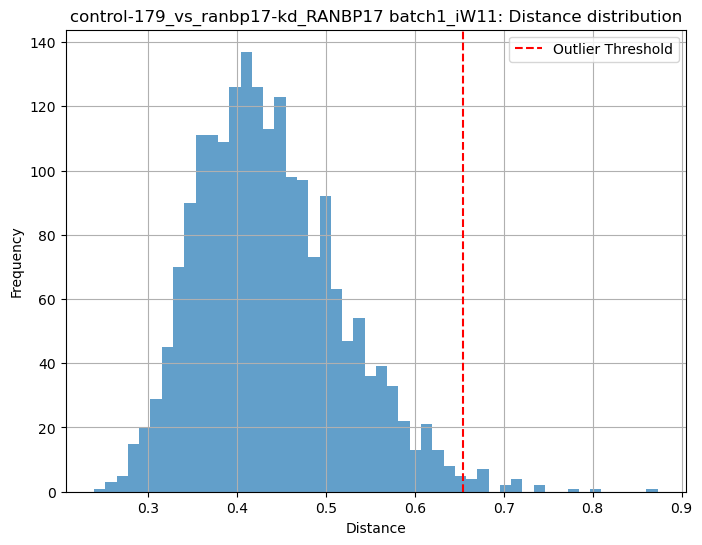

[control-179_vs_ranbp17-kd_RANBP17] control medoid: global idx 408 (of 976 control samples)
Marked 23 outliers across 1 group(s).


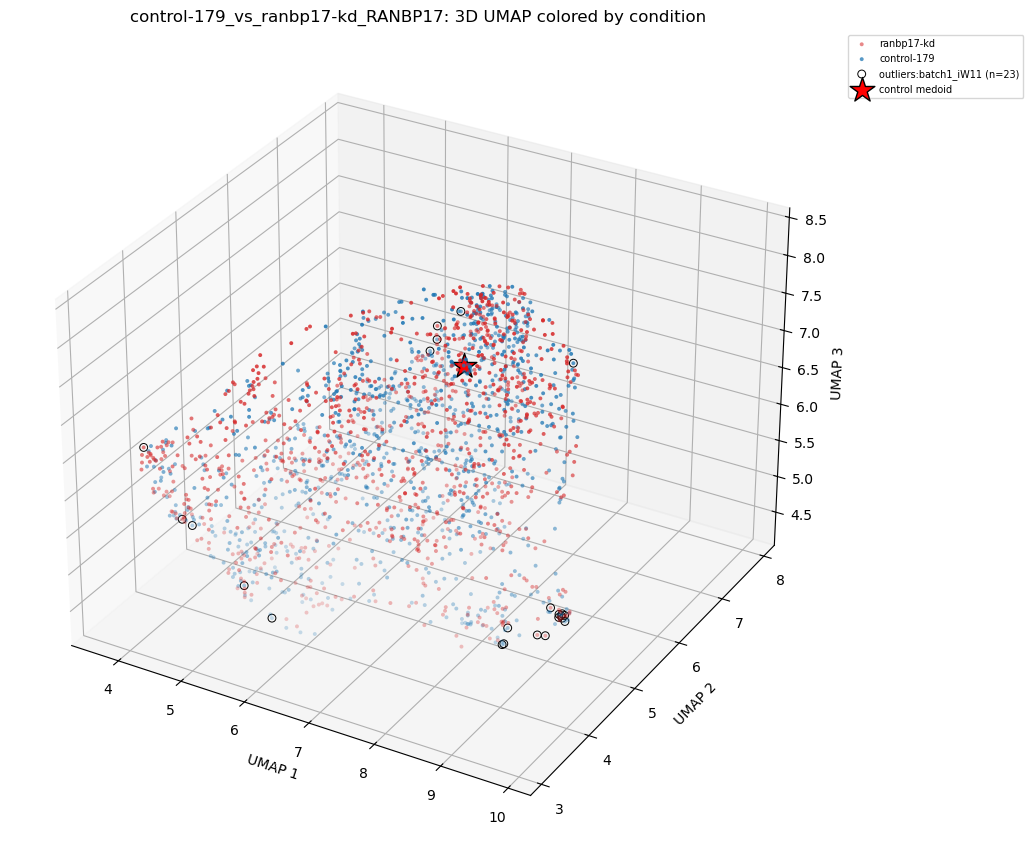

2026-05-20 11:08:15 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:15 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:15 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:15 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:15 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:15 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:15 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:15 INFO: [embeddings_utils._filter] conditions = ['control-179', 'both-kd']
2026-05-20 11:08:15 INFO: [load_embeddings] embeddings shape: (2034, 192)
2026-05-

[control-179_vs_both-kd_RANBP17] loading embeddings...
[control-179_vs_both-kd_RANBP17] loaded 2034 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


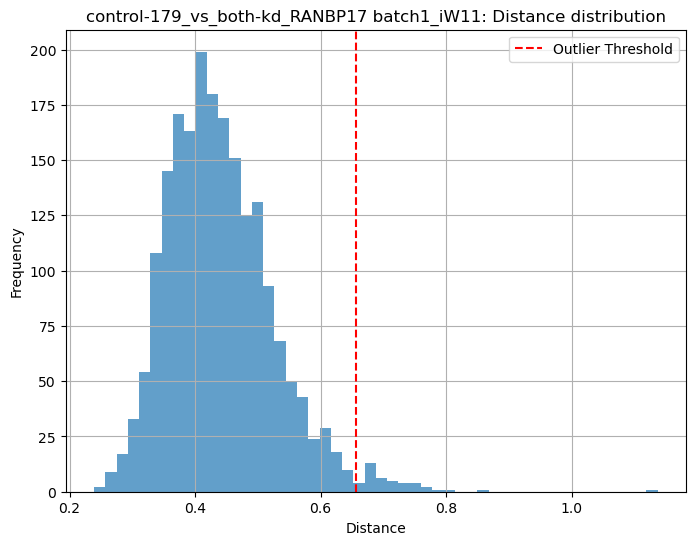

[control-179_vs_both-kd_RANBP17] control medoid: global idx 442 (of 976 control samples)
Marked 42 outliers across 1 group(s).


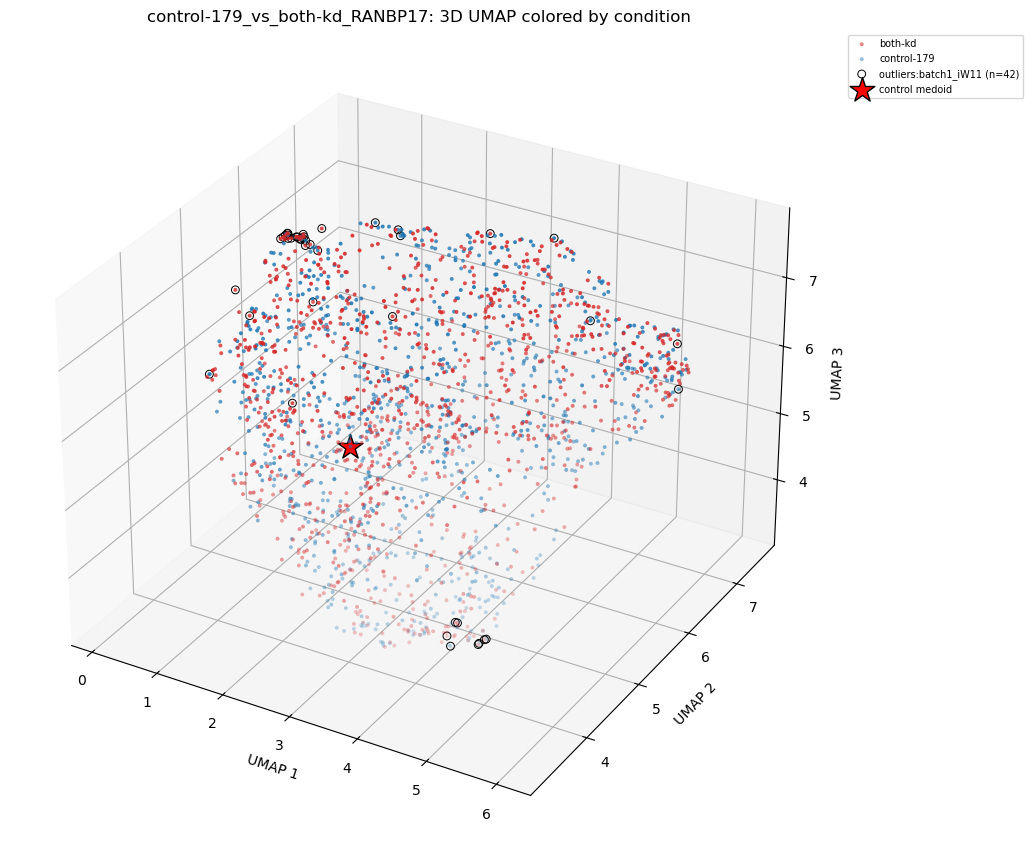

2026-05-20 11:08:20 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:20 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:20 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:20 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:20 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:21 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:21 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:21 INFO: [embeddings_utils._filter] conditions = ['control-180', 'tardp-kd']
2026-05-20 11:08:21 INFO: [load_embeddings] embeddings shape: (2187, 192)
2026-05

[control-180_vs_tardp-kd_RANBP17] loading embeddings...
[control-180_vs_tardp-kd_RANBP17] loaded 2187 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


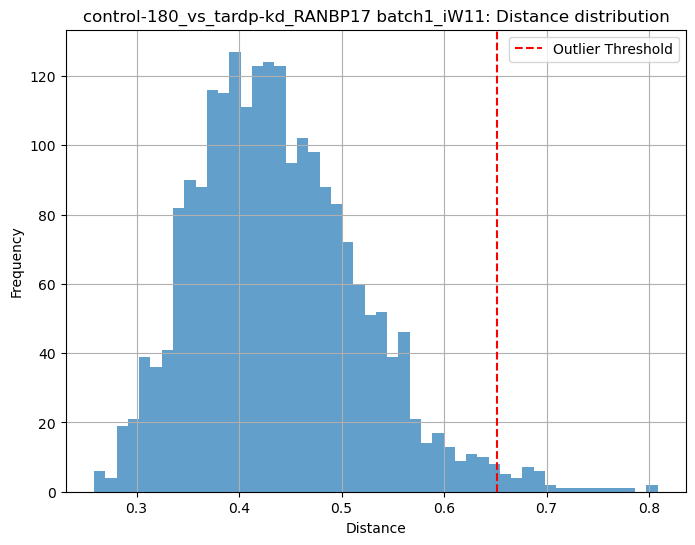

[control-180_vs_tardp-kd_RANBP17] control medoid: global idx 14 (of 1119 control samples)
Marked 34 outliers across 1 group(s).


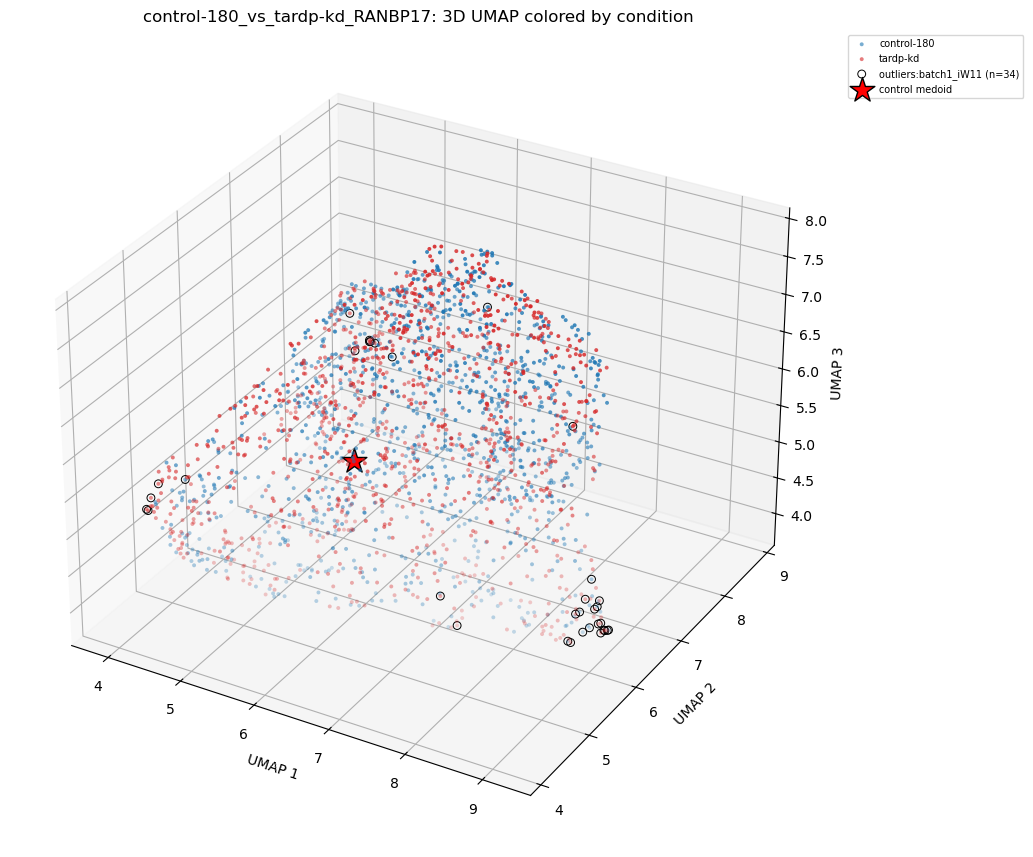

2026-05-20 11:08:27 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:27 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:27 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:27 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:27 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:27 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:27 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:27 INFO: [embeddings_utils._filter] conditions = ['control-180', 'ranbp17-kd']
2026-05-20 11:08:27 INFO: [load_embeddings] embeddings shape: (2113, 192)
2026-

[control-180_vs_ranbp17-kd_RANBP17] loading embeddings...
[control-180_vs_ranbp17-kd_RANBP17] loaded 2113 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


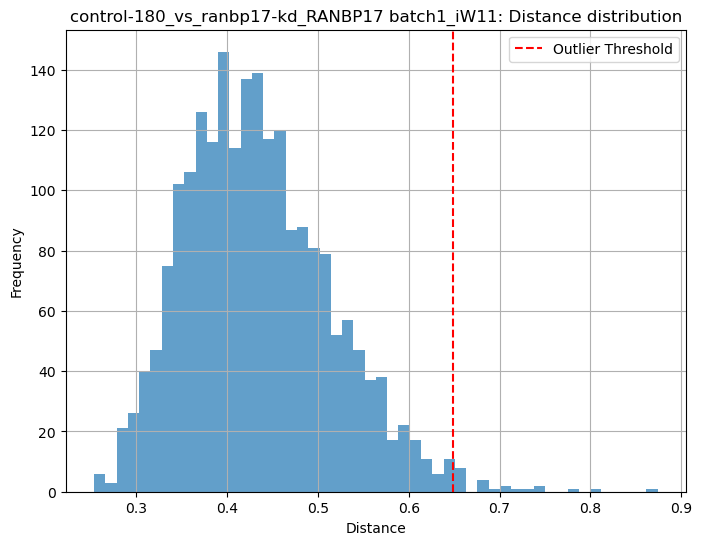

[control-180_vs_ranbp17-kd_RANBP17] control medoid: global idx 16 (of 1119 control samples)
Marked 23 outliers across 1 group(s).


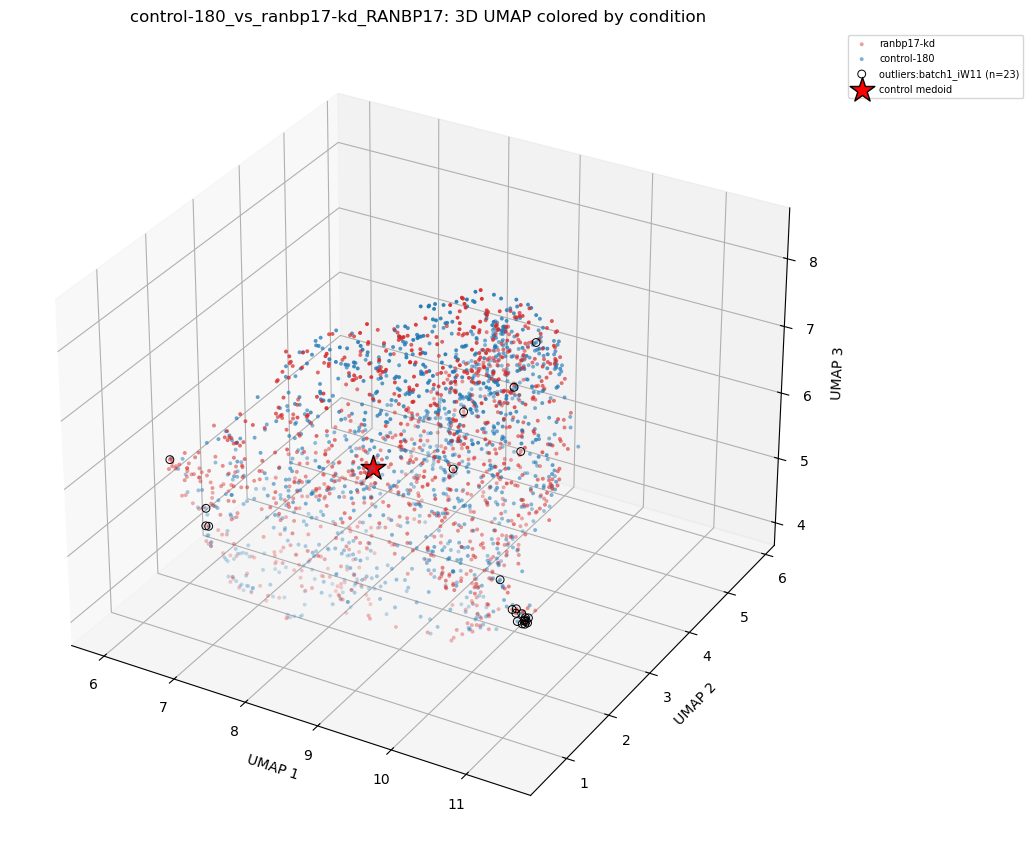

2026-05-20 11:08:33 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:33 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:33 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:33 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:33 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:33 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:33 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:33 INFO: [embeddings_utils._filter] conditions = ['control-180', 'both-kd']
2026-05-20 11:08:33 INFO: [load_embeddings] embeddings shape: (2177, 192)
2026-05-

[control-180_vs_both-kd_RANBP17] loading embeddings...
[control-180_vs_both-kd_RANBP17] loaded 2177 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


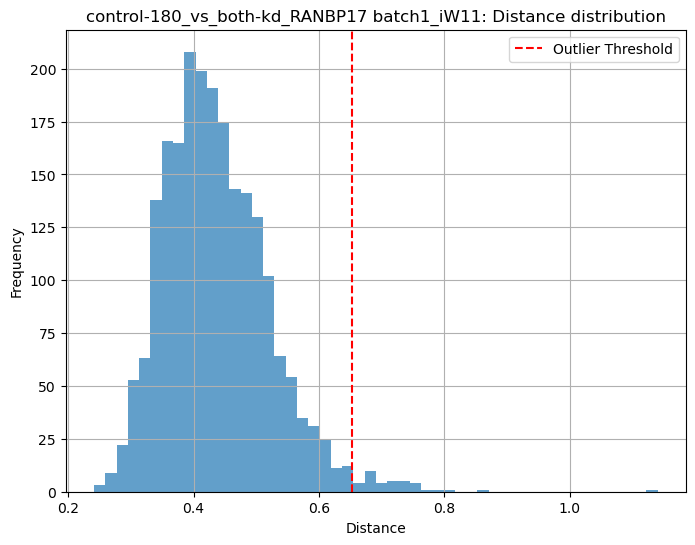

[control-180_vs_both-kd_RANBP17] control medoid: global idx 13 (of 1119 control samples)
Marked 39 outliers across 1 group(s).


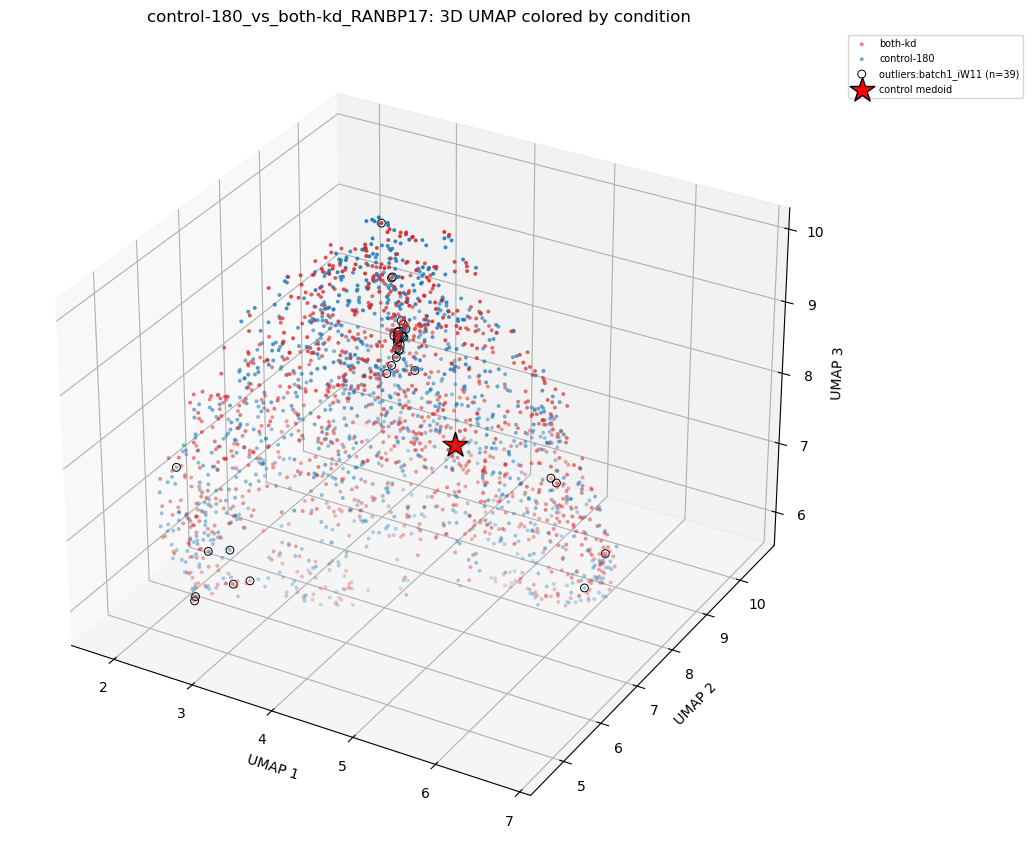

2026-05-20 11:08:39 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:39 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:39 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:39 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:39 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:39 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:39 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:39 INFO: [embeddings_utils._filter] conditions = ['untreated', 'tardp-kd']
2026-05-20 11:08:39 INFO: [load_embeddings] embeddings shape: (2297, 192)
2026-05-2

[untreated_vs_tardp-kd_RANBP17] loading embeddings...
[untreated_vs_tardp-kd_RANBP17] loaded 2297 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


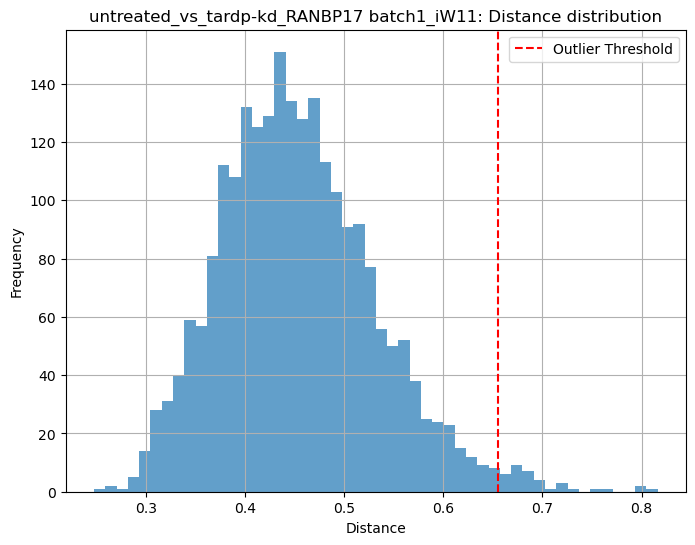

[untreated_vs_tardp-kd_RANBP17] control medoid: global idx 1930 (of 1229 control samples)
Marked 38 outliers across 1 group(s).


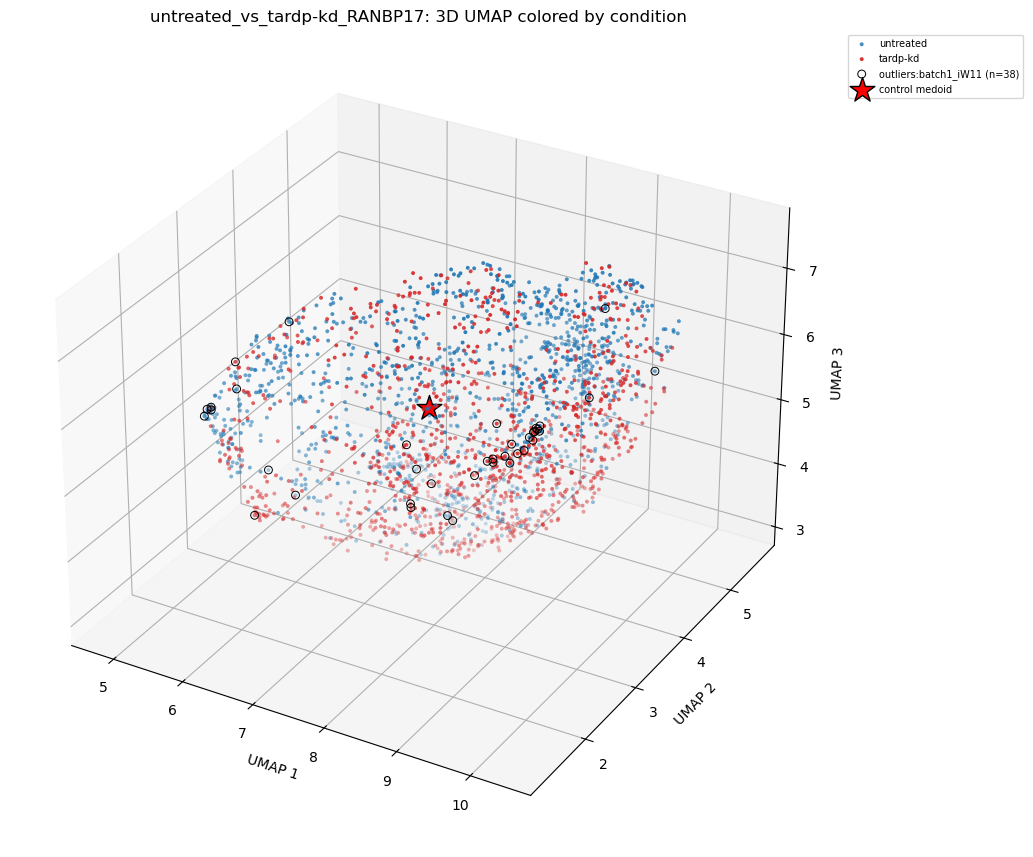

2026-05-20 11:08:45 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:45 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:45 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:45 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:45 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:45 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:45 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:45 INFO: [embeddings_utils._filter] conditions = ['untreated', 'ranbp17-kd']
2026-05-20 11:08:45 INFO: [load_embeddings] embeddings shape: (2223, 192)
2026-05

[untreated_vs_ranbp17-kd_RANBP17] loading embeddings...
[untreated_vs_ranbp17-kd_RANBP17] loaded 2223 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


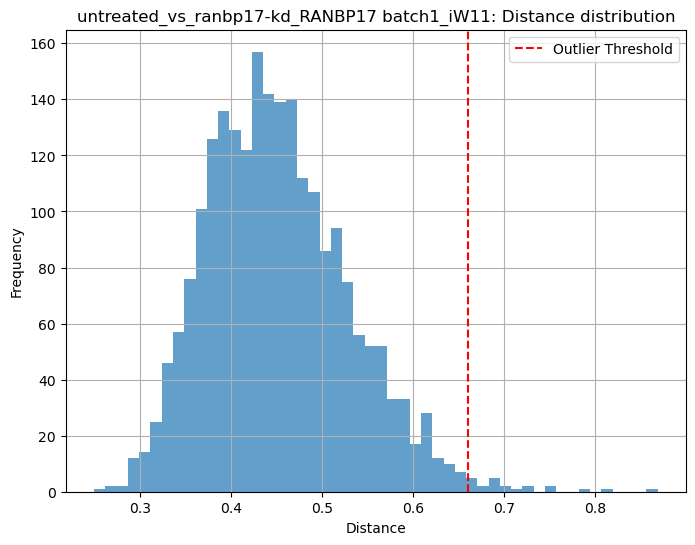

[untreated_vs_ranbp17-kd_RANBP17] control medoid: global idx 1867 (of 1229 control samples)
Marked 21 outliers across 1 group(s).


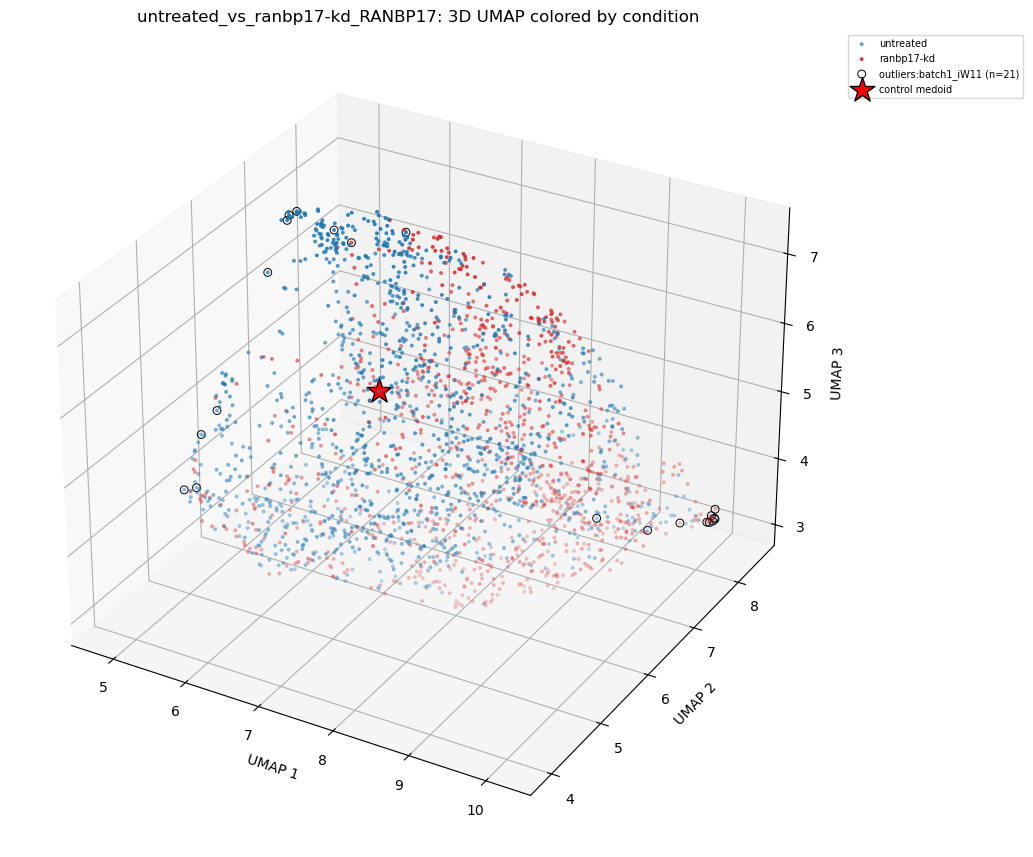

2026-05-20 11:08:51 INFO: [load_embeddings] multiplex=False
2026-05-20 11:08:51 INFO: [load_embeddings] experiment_type = RANBP17_exp
2026-05-20 11:08:51 INFO: [load_embeddings] input_folders = ['/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/batch1']
2026-05-20 11:08:51 INFO: [load_embeddings] model_output_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen
2026-05-20 11:08:51 INFO: [load_embeddings] embeddings_folder = /home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen/embeddings/RANBP17_exp/
2026-05-20 11:08:51 INFO: [embeddings_utils._filter] markers = ['RANBP17']
2026-05-20 11:08:51 INFO: [embeddings_utils._filter] cell_lines = ['iW11']
2026-05-20 11:08:51 INFO: [embeddings_utils._filter] conditions = ['untreated', 'both-kd']
2026-05-20 11:08:51 INFO: [load_embeddings] embeddings shape: (2287, 192)
2026-05-20

[untreated_vs_both-kd_RANBP17] loading embeddings...
[untreated_vs_both-kd_RANBP17] loaded 2287 embeddings; computing 3D UMAP...


/home/projects/hornsteinlab/giliwo/.conda/envs/nova/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


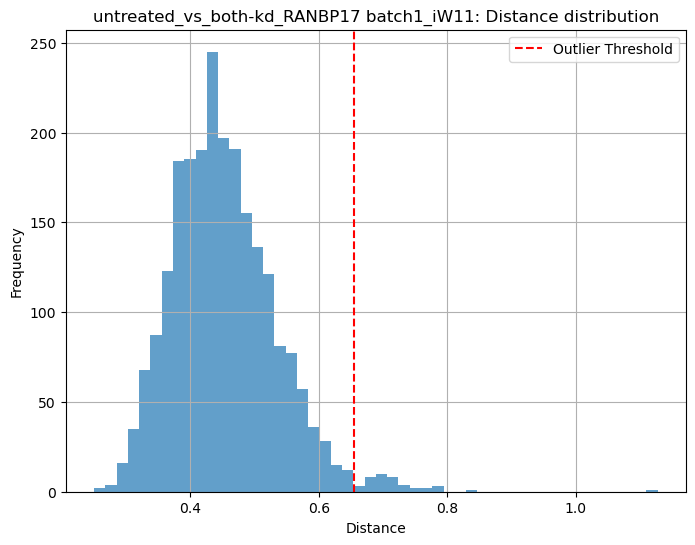

[untreated_vs_both-kd_RANBP17] control medoid: global idx 1959 (of 1229 control samples)
Marked 41 outliers across 1 group(s).


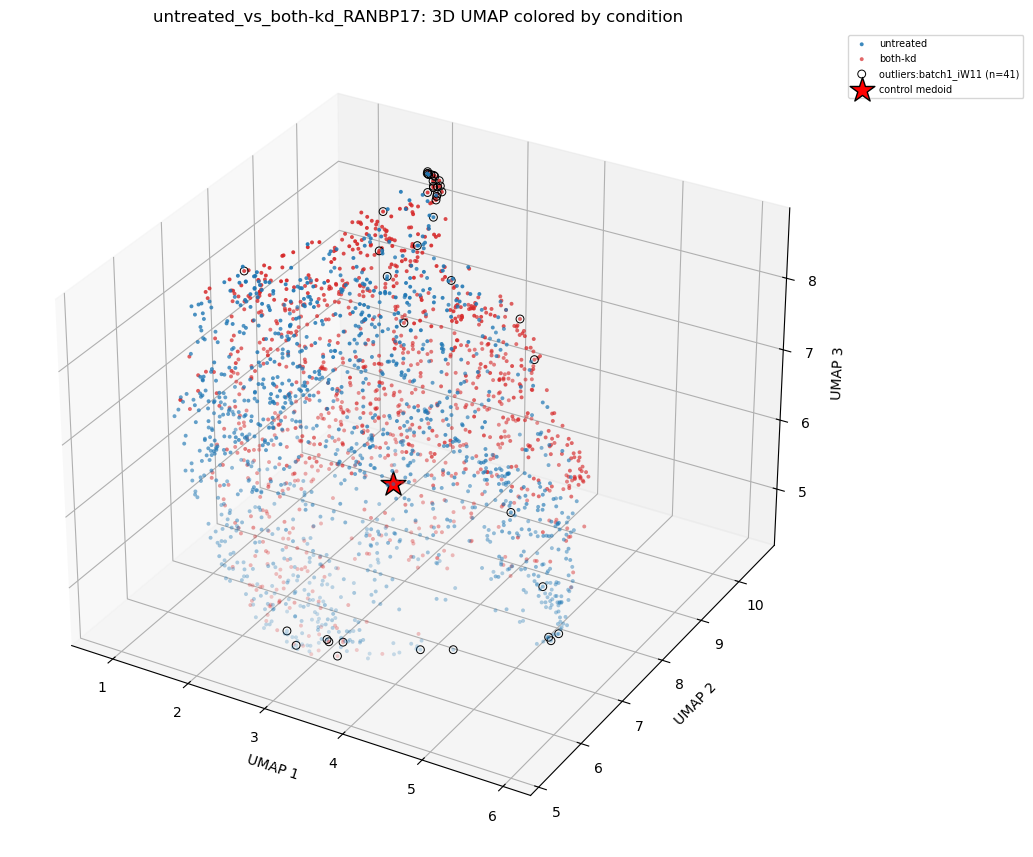

In [32]:
# --- Each KD vs. each control, looped (mirrors funova kd-vs-ctrl pattern) ---
CTRL_COLOR = "#1F77B4"
KD_COLOR   = "#D62728"
marker = "RANBP17"

kds_to_run   = KD_LIST            # e.g. ["ranbp17-kd"] for a single KD
ctrls_to_run = CONTROL_LIST       # e.g. ["control-179"] for a single control

for ctrl in ctrls_to_run:
    for kd in kds_to_run:
        spec = {
            "data": {
                "name": f"{ctrl}_vs_{kd}_{marker}",
                "batches": BATCHES,
                "cell_lines": CELL_LINES,
                "conditions": [ctrl, kd],
                "markers": [marker],
                "markers_to_exclude": MARKERS_TO_EXCLUDE,
            },
            "plot": {
                "color_by": "condition",
                "size": 8,
                "color_overrides": {ctrl: CTRL_COLOR, kd: KD_COLOR},
                "n_components": 3,
                "alpha_z_gradient": True,
                "control_conditions": [ctrl],
            },
        }

        result = run_umap_spec(
            spec,
            output_dir=None,
            d=D,
            find_outliers_per_group=True,
            num_imgs=0,
        )